## Morphology & Mask Cleanup
A raw HSV mask is rarely clean. This section applies erosion, opening, closing, gradient outline, examines direct BGR morphology, and demonstrates morphological variants on a thin-stroke image.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 100

def show_row(titles, imgs, cmaps=None, figsize=(16,4)):
    if cmaps is None:
        cmaps = [None] * len(imgs)
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1:
        axes = [axes]
    for ax, title, img, cmap in zip(axes, titles, imgs, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

base = os.path.join('images')

# 11. Take your banana HSV mask from Part A. Apply erosion with a 5×5 kernel. What happens to the mask?

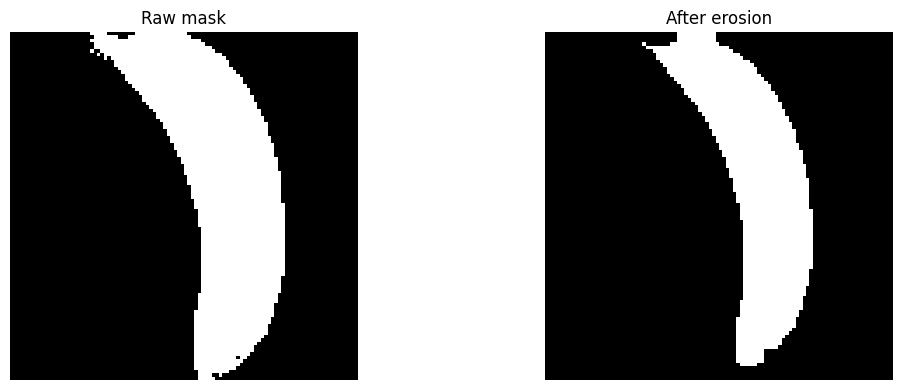

In [2]:
banana_bgr = cv2.imread(os.path.join(base, 'banana.jpg'))
if banana_bgr is None:
    raise FileNotFoundError('banana.jpg not found')
banana_rgb = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2RGB)
banana_hsv = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2HSV)

lower_banana = np.array([10, 50, 50])
upper_banana = np.array([40, 255, 255])
raw_mask = cv2.inRange(banana_hsv, lower_banana, upper_banana)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
eroded_mask = cv2.erode(raw_mask, kernel, iterations=1)

show_row(
    ['Raw mask', 'After erosion'],
    [raw_mask, eroded_mask],
    ['gray', 'gray'],
    figsize=(12,4)
)

Erosion shrinks the mask and removes small spurious blobs, but it also removes thin banana boundaries and gaps.

# 12. Apply opening (erosion then dilation) to remove noise.

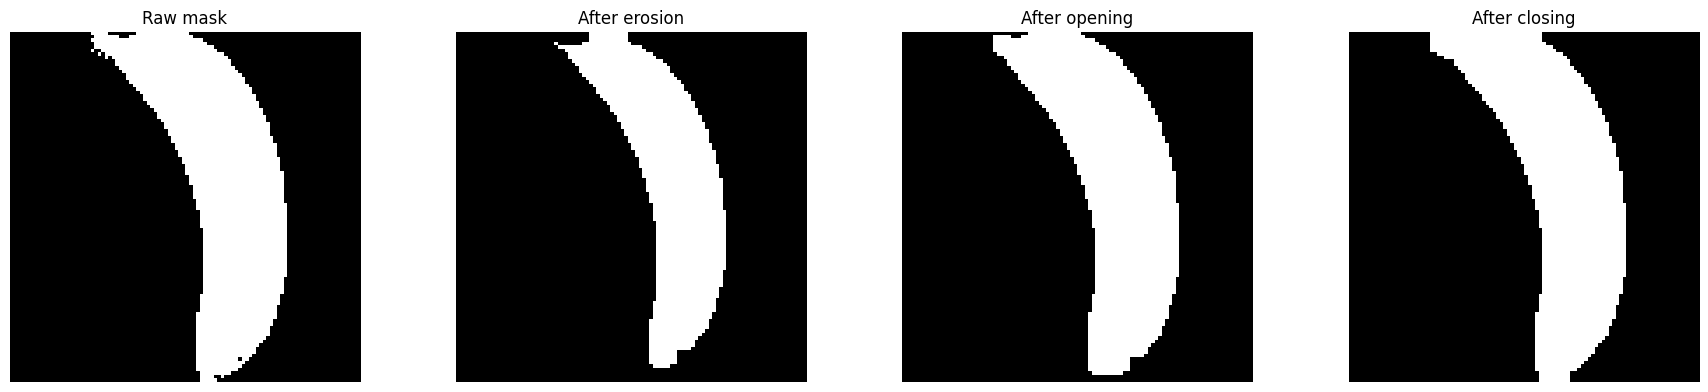

In [3]:
opened_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
closed_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)

show_row(
    ['Raw mask', 'After erosion', 'After opening', 'After closing'],
    [raw_mask, eroded_mask, opened_mask, closed_mask],
    ['gray'] * 4,
    figsize=(18,4)
)

Opening removes isolated noise blobs; closing fills small holes and shadow gaps in the banana mask.


# 13.  Apply the morphological gradient (dilation − erosion) to extract just the outline of the banana. Overlay it on the original image in green.


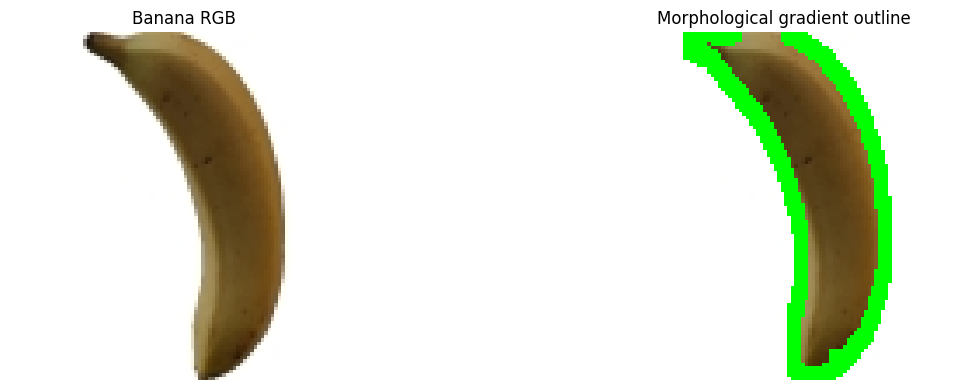

In [4]:
gradient_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_GRADIENT, kernel)
outline = banana_rgb.copy()
outline[gradient_mask == 255] = [0, 255, 0]

show_row(
    ['Banana RGB', 'Morphological gradient outline'],
    [banana_rgb, outline],
    [None, None],
    figsize=(14,4)
)

Morphological gradient extracts the banana outline. The green overlay shows the boundary region clearly.

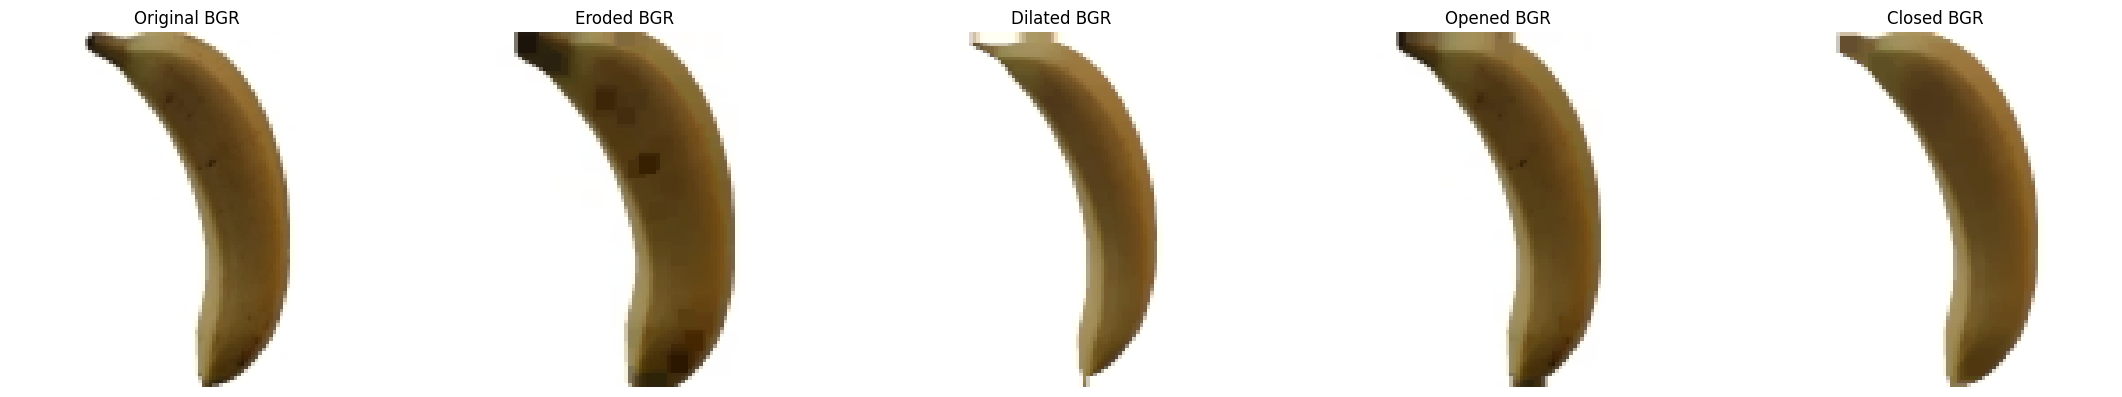

In [5]:
banana_eroded = cv2.erode(banana_bgr, kernel, iterations=1)
banana_dilated = cv2.dilate(banana_bgr, kernel, iterations=1)
banana_opened = cv2.morphologyEx(banana_bgr, cv2.MORPH_OPEN, kernel)
banana_closed = cv2.morphologyEx(banana_bgr, cv2.MORPH_CLOSE, kernel)

show_row(
    ['Original BGR', 'Eroded BGR', 'Dilated BGR', 'Opened BGR', 'Closed BGR'],
    [banana_rgb, cv2.cvtColor(banana_eroded, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_dilated, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_opened, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_closed, cv2.COLOR_BGR2RGB)],
    [None] * 5,
    figsize=(22,4)
)

Direct morphology on BGR distorts the image and changes color regions rather than cleaning a binary mask. It is not a substitute for mask cleanup.

# 14. Reflection: what would happen if you applied morphological operations directly to the BGR fruit image instead of the binary mask? Try it and describe what you see.

Applying morphology directly to the BGR image changes colors and blends regions instead of cleaning a mask. The operations act on each channel and distort the fruit, so you lose the clear shape extraction benefits that come from processing a binary mask.

# 15. Demo with j.png: apply erosion, dilation, opening, closing, Top Hat, and Black Hat. Show all six results. Which operation isolates the thin strokes?

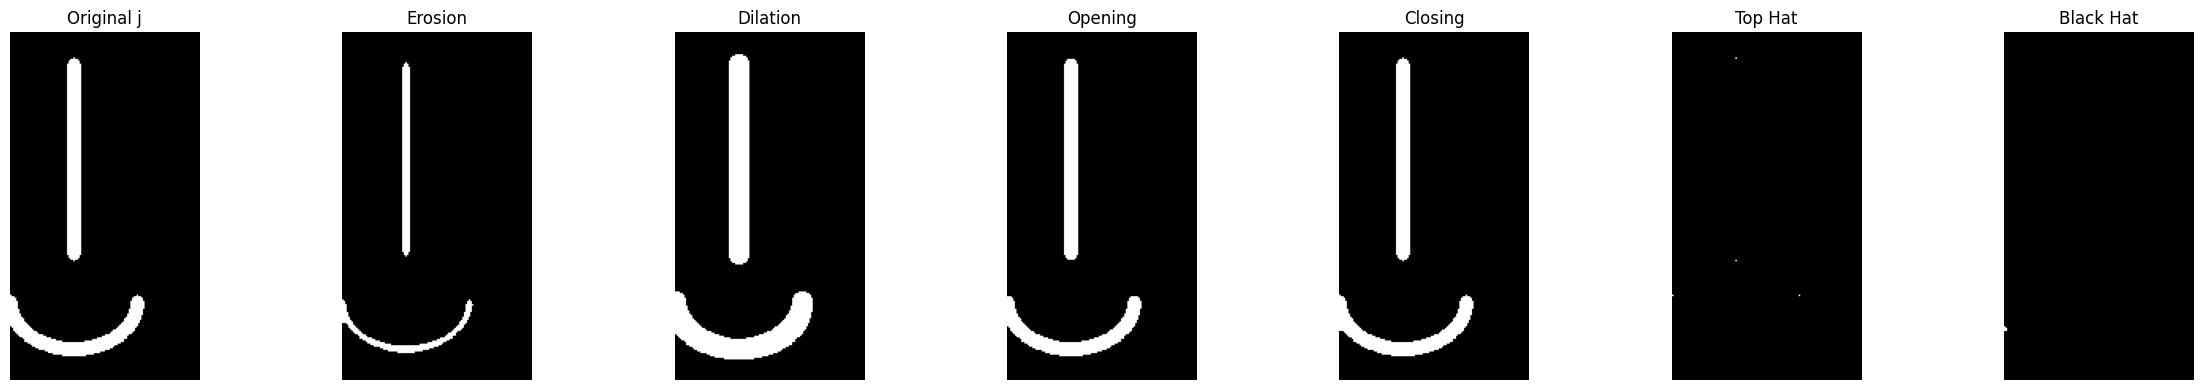

In [6]:
j_path = os.path.join(base, 'j.png')
if os.path.exists(j_path):
    j_img = cv2.imread(j_path, cv2.IMREAD_GRAYSCALE)
else:
    j_img = np.zeros((220,120), dtype=np.uint8)
    cv2.line(j_img, (40, 20), (40, 140), 255, 8)
    cv2.ellipse(j_img, (40, 170), (40, 30), 0, 0, 180, 255, 8)
    cv2.imwrite(j_path, j_img)
    print('j.png not found; generated a synthetic thin-stroke demo image and saved it to images/j.png.')

j_eroded = cv2.erode(j_img, kernel, iterations=1)
j_dilated = cv2.dilate(j_img, kernel, iterations=1)
j_opened = cv2.morphologyEx(j_img, cv2.MORPH_OPEN, kernel)
j_closed = cv2.morphologyEx(j_img, cv2.MORPH_CLOSE, kernel)
j_tophat = cv2.morphologyEx(j_img, cv2.MORPH_TOPHAT, kernel)
j_blackhat = cv2.morphologyEx(j_img, cv2.MORPH_BLACKHAT, kernel)

show_row(
    ['Original j', 'Erosion', 'Dilation', 'Opening', 'Closing', 'Top Hat', 'Black Hat'],
    [j_img, j_eroded, j_dilated, j_opened, j_closed, j_tophat, j_blackhat],
    ['gray'] * 7,
    figsize=(24,4)
)


Top Hat isolates bright thin strokes; Black Hat isolates dark background features around bright strokes.